In [2]:
import cv2
import numpy as np
import pathlib
import matplotlib.pyplot as plt

class ProcesamientoImagen:
    def __init__(self, imagen, titulo="Imagen", es_color=False):
        self.es_color = es_color
        if isinstance(imagen, (str, pathlib.Path)):
            if es_color:
                tensor_bgr = cv2.imread(str(imagen), cv2.IMREAD_COLOR)
                self.tensor = cv2.cvtColor(tensor_bgr, cv2.COLOR_BGR2RGB)
            else:
                self.tensor = cv2.imread(str(imagen), cv2.IMREAD_GRAYSCALE)
                
            if self.tensor is None:
                raise ValueError(f"Error: No se pudo cargar la imagen en la ruta {imagen}")
        else:
            self.tensor = imagen
            
        self.titulo = titulo

    def to_negative(self) -> "ProcesamientoImagen":
        """Aplica el negativo usando operaciones bit a bit de OpenCV."""
        tensor_neg = cv2.bitwise_not(self.tensor)
        return ProcesamientoImagen(tensor_neg, titulo=f"Negativo de {self.titulo}", es_color=self.es_color)

    def gamma_transform(self, gamma: float) -> "ProcesamientoImagen":
        """Aplica transformación Gamma usando una Look-Up Table (LUT)."""
        table = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
        
        tensor_gamma = cv2.LUT(self.tensor, table)
        return ProcesamientoImagen(tensor_gamma, titulo=f"Gamma (g={gamma})", es_color=self.es_color)

    def binarize(self, umbral: int = 127) -> "ProcesamientoImagen":
        """Binarizado global clásico."""
        _, tensor_bin = cv2.threshold(self.tensor, umbral, 255, cv2.THRESH_BINARY)
        return ProcesamientoImagen(tensor_bin, titulo=f"Binario (th={umbral})", es_color=self.es_color)

    def interpolar(self, r, s) -> "ProcesamientoImagen":
        """
        Transformación de intensidad por puntos de control.
        r: puntos de entrada  (ej. [0, 100, 255])
        s: puntos de salida   (ej. [0, 200, 255])
        Interpola linealmente entre los puntos y aplica el mapeo a cada píxel.
        """
        lut = np.interp(np.arange(256), r, s).astype("uint8")
        tensor_interp = cv2.LUT(self.tensor, lut)
        return ProcesamientoImagen(tensor_interp, titulo=f"Interpolado de {self.titulo}", es_color=self.es_color)
    
    def show_funcion_interpolada(self, r, s, color='blue'):
        """Muestra la función de interpolación como una gráfica."""
        x = np.arange(256)
        y = np.interp(x, r, s)
        
        plt.figure(figsize=(4, 4))
        plt.plot(x, y, color=color, linewidth=2)
        plt.title("Función de Interpolación")
        plt.xlabel("Intensidad Original (r)")
        plt.ylabel("Intensidad Transformada (s)")
        plt.xlim(0, 256)
        plt.ylim(0, 256)
        plt.grid()
        plt.show()

    def pseudocolor(self, tr_r, ts_r, tr_g, ts_g, tr_b, ts_b) -> "ProcesamientoImagen":
        """
        Aplica pseudocolor a una imagen en escala de grises usando tres funciones
        de transformación independientes Tr, Tg, Tb.

        Parámetros:
            tr_r, ts_r: puntos de control para el canal Rojo   (entrada, salida)
            tr_g, ts_g: puntos de control para el canal Verde  (entrada, salida)
            tr_b, ts_b: puntos de control para el canal Azul   (entrada, salida)

        Retorna una nueva instancia ProcesamientoImagen a color (es_color=True).
        """
        if self.es_color:
            raise ValueError("pseudocolor solo aplica a imágenes en escala de grises.")

        lut_r = np.interp(np.arange(256), tr_r, ts_r).astype("uint8")
        lut_g = np.interp(np.arange(256), tr_g, ts_g).astype("uint8")
        lut_b = np.interp(np.arange(256), tr_b, ts_b).astype("uint8")

        canal_r = cv2.LUT(self.tensor, lut_r)
        canal_g = cv2.LUT(self.tensor, lut_g)
        canal_b = cv2.LUT(self.tensor, lut_b)

        tensor_color = cv2.merge((canal_r, canal_g, canal_b))
        return ProcesamientoImagen(tensor_color, titulo=f"Pseudocolor de {self.titulo}", es_color=True)

    def ecualizar(self) -> "ProcesamientoImagen":
        """Ecualización de histograma global. Soporta B/N y Color."""
        
        if not self.es_color:
            tensor_eq = cv2.equalizeHist(self.tensor)
            
        else:
            hsv = cv2.cvtColor(self.tensor, cv2.COLOR_RGB2HSV)
            
            h, s, v = cv2.split(hsv)
            
            v_eq = cv2.equalizeHist(v)
            
            hsv_eq = cv2.merge((h, s, v_eq))
            
            tensor_eq = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2RGB)
            
        return ProcesamientoImagen(tensor_eq, titulo=f"Ecualizado de {self.titulo}", es_color=self.es_color)

    def show(self):
        """Muestra la imagen usando las ventanas de OpenCV."""
        cv2.imshow(self.titulo, self.tensor)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        return self

    def show_jupyter(self, figsize_gray=(10, 4), figsize_color=(12, 8)) -> "ProcesamientoImagen":
        """Muestra la imagen y su histograma basado directamente en la bandera es_color."""
        
        if self.es_color:
            fig, ((ax_img, ax_hist_r), (ax_hist_g, ax_hist_b)) = plt.subplots(2, 2, figsize=figsize_color)
            
            ax_img.imshow(self.tensor)
            ax_img.set_title(self.titulo)
            ax_img.axis('off')

            colores = [('Rojo', 'red', ax_hist_r), ('Verde', 'green', ax_hist_g), ('Azul', 'blue', ax_hist_b)]
            for i, (nombre, color_plot, ax) in enumerate(colores):
                hist = cv2.calcHist([self.tensor], [i], None, [256], [0, 256])
                ax.plot(hist, color=color_plot, linewidth=1.5)
                ax.fill_between(range(256), hist.flatten(), color=color_plot, alpha=0.1)
                ax.set_title(f"Canal {nombre}")
                ax.set_xlim([0, 256])
                
        else:
            fig, (ax_img, ax_hist) = plt.subplots(1, 2, figsize=figsize_gray)
            
            ax_img.imshow(self.tensor, cmap='gray')
            ax_img.set_title(self.titulo)
            ax_img.axis('off')
            
            n, _, _ = ax_hist.hist(self.tensor.ravel(), bins=256, range=(0, 256), color='gray')
            ax_hist.fill_between(range(256), n, color='red', alpha=0.4)
            ax_hist.set_title("Histograma Grises")
            ax_hist.set_xlim([0, 256])

        plt.tight_layout()
        plt.show()
        return self
    
    def log_transform(self) -> "ProcesamientoImagen":
        """Transformación logarítmica: s = c * log(1 + r), normalizada a [0, 255]."""
        c = 255 / np.log1p(255)
        lut = (c * np.log1p(np.arange(256))).astype("uint8")
        tensor_log = cv2.LUT(self.tensor, lut)
        return ProcesamientoImagen(tensor_log, titulo=f"Log de {self.titulo}", es_color=self.es_color)

    def trace(self) -> "ProcesamientoImagen":
        """
        Abre una ventana interactiva. Al mover el ratón sobre la imagen,
        muestra las coordenadas (X, Y) y la intensidad del píxel.
        """
        
        if self.es_color:
            tensor_display = cv2.cvtColor(self.tensor, cv2.COLOR_RGB2BGR)
        else:
            tensor_display = self.tensor.copy()
        
        def mouse_callback(event, x, y, flags, param):
            if event == cv2.EVENT_MOUSEMOVE:
                img_temp = tensor_display.copy()
                
                intensidad = self.tensor[y, x]
                
                if self.es_color:
                    texto = f"RGB: {intensidad}"
                else:
                    texto = f"Intensidad: {intensidad}"
                
                cv2.rectangle(img_temp, (5, 5), (400, 40), (0, 0, 0), -1)
                
                cv2.putText(img_temp, texto, (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
                
                cv2.imshow(self.titulo, img_temp)

        cv2.namedWindow(self.titulo)
        cv2.setMouseCallback(self.titulo, mouse_callback)
        
        cv2.imshow(self.titulo, self.tensor)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        
        return self
    
    def ecualizado(self) -> "ProcesamientoImagen":
        """Ecualiza cada canal de forma independiente (RGB separado)."""
        if self.es_color:
            r, g, b = cv2.split(self.tensor)
            r_eq = cv2.equalizeHist(r)
            g_eq = cv2.equalizeHist(g)
            b_eq = cv2.equalizeHist(b)
            tensor_eq = cv2.merge((r_eq, g_eq, b_eq))
        else:
            tensor_eq = cv2.equalizeHist(self.tensor)

        return ProcesamientoImagen(
            tensor_eq,
            titulo=f"Ecualizado RGB separado de {self.titulo}",
            es_color=self.es_color
        )
    
    def save(self, ruta: str):
        """Guarda la imagen en la ruta especificada."""
        if self.es_color:
            tensor_bgr = cv2.cvtColor(self.tensor, cv2.COLOR_RGB2BGR)
            cv2.imwrite(ruta, tensor_bgr)
        else:
            cv2.imwrite(ruta, self.tensor)

In [4]:
import pathlib

ruta = pathlib.Path.cwd() / "imagenes"

def cargar_imagen(nombre_archivo):
    return ruta / nombre_archivo

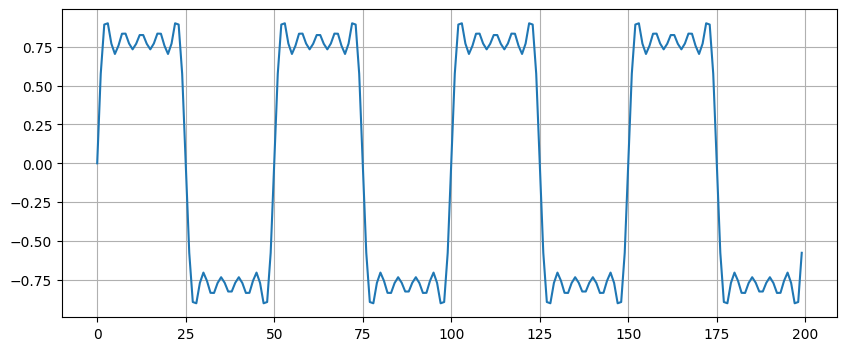

In [9]:
frecuencia = 2 * np.pi / 50 # 50 pixeles para completar un ciclo
f = lambda i: np.sin(frecuencia * i) + (1/3) * np.sin(3* frecuencia * i) + (1/5) * np.sin(5*frecuencia * i) + (1/7) * np.sin(7*frecuencia * i) + (1/9) * np.sin(9*frecuencia * i)
plt.figure(figsize=(10, 4))
plt.plot([f(i) for i in range(200)])
plt.grid()
plt.show()

In [13]:
def f2(i, n=5):
    resultado = 0
    for k in range(n):
        resultado += (1/(2*k+1)) * np.sin((2*k+1) * frecuencia * i)
    return resultado

Imagen es el espacio de la imagen

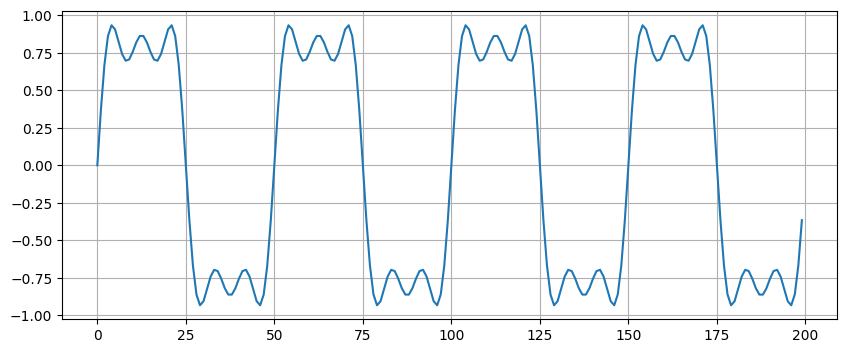

In [15]:
n = 3
plt.figure(figsize=(10, 4))
plt.plot([f2(i, n=n) for i in range(200)])
plt.grid()
plt.show()

La transformada de fourier tiene un espejo, la primera mitad es un espejo de la segunda
Eje x es frecuencia, cuantas veces se repite mi senial senoidal 
El eje y es la amplitud
Tomando de ejemplo con n = 3. El eje y en la primera frecuencia va a ser de 7.0711 porque es con la de un septimo de la serie senoidal, el siguiente eje es 2 y cacho porque es un tercio del valor de 7.07111
En el eje x cuando multiplicas la fracion por el numero de fraccion es la frecuencia de cada una (4*3, 4*5, 4*7)

Cualquier señal periodica la puedo sintentizar con sumar señales senoidales

Imagen en el espacio de frecuencia

Text(0.5, 1.0, 'Magnitud de la Transformada de Fourier')

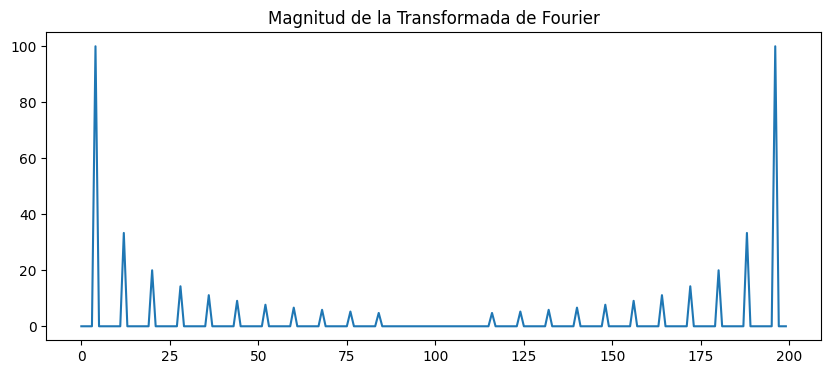

In [25]:
i = 200
n = 11
s = f2(i, n)
# Transformada de Fourier discreta de la señal s
S = np.fft.fft([f2(j, n) for j in range(i)])
plt.figure(figsize=(10, 4))
plt.plot(np.abs(S))
plt.title("Magnitud de la Transformada de Fourier")

Si sumas la señal con una frecuencia 4 con una de frecuencia 8, no da una frecuencia 6, resulta en una señal de suma frecuancia 4 con 8

In [ ]:
# Agregar una suma de senoidales con frecuencias diferentes para mostrar el efecto de sumarlas

Tirar las 2 componentes de frecuencia mas baja, sumando a la funcion de senoidal para quitar valores megativos y aplicando la funcion inversa de fourier se puede filtar la funcion